In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
!pip freeze > '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/rf_energia_eolica_requirements.txt'

In [ ]:
!pip freeze > /content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/rf_energia_solar_requirements.txt

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import numpy as np
import folium

In [ ]:
# --- Etapa 1: Carregar e Preparar os Dados para o Modelo Eólico ---

print("--- Iniciando Etapa 1: Preparação dos Dados para Regressão Eólica ---")
try:
    df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/FACT_LOCALIDADE_CLIMA_202509272358.csv')
except FileNotFoundError:
    print("Erro: Arquivo 'FACT_LOCALIDADE_CLIMA_202509272358.csv' não encontrado. Faça o upload do arquivo.")
    exit()

# Padroniza os nomes das colunas para minúsculas
df_train.columns = [col.replace('"', '').lower() for col in df_train.columns]

# Remove linhas com dados faltantes (NaN)
print("\nLimpando dados faltantes no arquivo de treino...")
df_train.dropna(inplace=True)
print("Limpeza do arquivo de treino concluída.")

--- Iniciando Etapa 1: Preparação dos Dados para Regressão Eólica ---

Limpando dados faltantes no arquivo de treino...
Limpeza do arquivo de treino concluída.


In [ ]:
# --- Etapa 2: Treinamento do Modelo de Regressão para Vento ---

print("\n--- Iniciando Etapa 2: Treinamento do Modelo de Regressão Eólica ---")

# A variável alvo.
target = 'wind_speed_10m_mean'

# Outras variáveis de vento foram excluídas para não atrapalhar o modelo.
features = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'relative_humidity_2m_mean', 'surface_pressure_mean',
    'shortwave_radiation_sum', 'precipitation_sum'
]

print("\nFeatures que serão usadas no modelo:")
print(features)

X = df_train[features]
y = df_train[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nIniciando o treinamento do modelo eólico...")
model_eolico = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_eolico.fit(X_train, y_train)
print("Treinamento concluído.")

# Avalia a performance do modelo
y_pred = model_eolico.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nResultados da Avaliação do Modelo Eólico:")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse:.4f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {np.sqrt(mse):.4f} m/s")


--- Iniciando Etapa 2: Treinamento do Modelo de Regressão Eólica ---

Features que serão usadas no modelo:
['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'surface_pressure_mean', 'shortwave_radiation_sum', 'precipitation_sum']

Iniciando o treinamento do modelo eólico...
Treinamento concluído.

Resultados da Avaliação do Modelo Eólico:
R² (Coeficiente de Determinação): 0.7275
MSE (Erro Quadrático Médio): 9.9763
RMSE (Raiz do Erro Quadrático Médio): 3.1585 m/s


In [ ]:
# --- Etapa 3: Salvar o Modelo Treinado ---

print("\n--- Iniciando Etapa 3: Salvando o Modelo de Regressão Eólica ---")
model_filename_eolico = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/random_forest_regressor_eolico.joblib'
joblib.dump(model_eolico, model_filename_eolico)
print(f"Modelo salvo com sucesso no arquivo: {model_filename_eolico}")


--- Iniciando Etapa 3: Salvando o Modelo de Regressão Eólica ---
Modelo salvo com sucesso no arquivo: /content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/random_forest_regressor_eolico.joblib


In [ ]:
# --- Etapa 4: Prever o Potencial Eólico para Goiás ---

print("\n--- Iniciando Etapa 4: Prevendo a Velocidade do Vento para Goiás ---")
try:
    df_goias = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/goias_clima_era5_diario_completo.csv')
except FileNotFoundError:
    print("Erro: Arquivo 'goias_clima_era5_diario_completo.csv' não encontrado. Faça o upload do arquivo.")
    exit()

if df_goias[features].isnull().sum().any():
    print("\nAlerta: Removendo linhas com NaN nos dados de Goiás.")
    df_goias.dropna(subset=features, inplace=True)

X_goias = df_goias[features]
loaded_model_eolico = joblib.load(model_filename_eolico)
print(f"\nModelo '{model_filename_eolico}' carregado com sucesso.")

goias_wind_predictions = loaded_model_eolico.predict(X_goias)
df_goias['VELOCIDADE_VENTO_PREDITA'] = goias_wind_predictions

# Salvar as previsões detalhadas em um novo CSV
results_filename_eolico = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/previsoes_potencial_eolico_goias.csv'
df_goias.to_csv(results_filename_eolico, index=False)
print(f"\nPrevisões detalhadas salvas em: {results_filename_eolico}")


--- Iniciando Etapa 4: Prevendo a Velocidade do Vento para Goiás ---

Alerta: Removendo linhas com NaN nos dados de Goiás.

Modelo '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/random_forest_regressor_eolico.joblib' carregado com sucesso.

Previsões detalhadas salvas em: /content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/previsoes_potencial_eolico_goias.csv


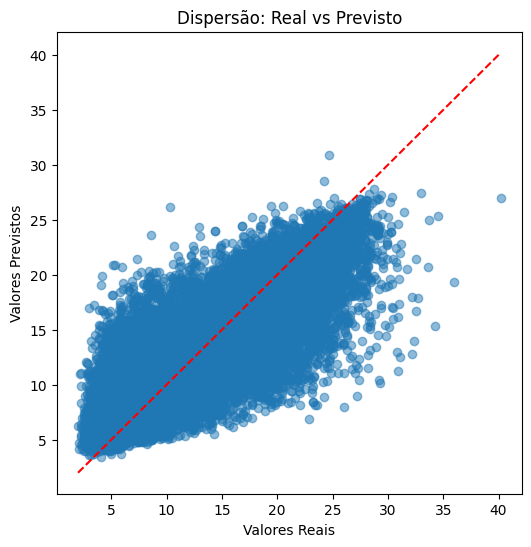

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Dispersão: Real vs Previsto')
plt.show()

In [ ]:
# --- Etapa 5: Gerar o Mapa de Potencial Eólico ---
print("\n--- Iniciando Etapa 5: Gerando o Mapa ---")
potencial_eolico = df_goias.groupby('municipio').agg(
    vento_medio_predito=('VELOCIDADE_VENTO_PREDITA', 'mean'),
    lat=('lat', 'first'),
    lon=('lon', 'first')
).reset_index()
top_50_municipios_eolico = potencial_eolico.sort_values(by='vento_medio_predito', ascending=False).head(10)

mapa_goias_eolico = folium.Map(location=[-15.98, -49.86], zoom_start=7, tiles='OpenStreetMap')

for index, row in top_50_municipios_eolico.iterrows():
    popup_text = f"<b>Município:</b> {row['municipio']}<br><b>Vento Médio:</b> {row['vento_medio_predito']:.2f} m/s"

    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=folium.Tooltip(
            text=row['municipio'],
            permanent=True,
            direction='top',
            offset=[0, -10],
            style="font-weight:bold; font-size:10px;"
        )
    ).add_to(mapa_goias_eolico)

mapa_filename_eolico = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/mapa_potencial_eolico_goias.html'
mapa_goias_eolico.save(mapa_filename_eolico)
print(f"\nMapa salvo como '{mapa_filename_eolico}'.")

mapa_goias_eolico


--- Iniciando Etapa 5: Gerando o Mapa ---

Mapa salvo como '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/mapa_potencial_eolico_goias.html'.
